<a href="https://colab.research.google.com/github/Renu-1205/Credit-Fraud-Detection/blob/main/Credit_Fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  COMPLETE FRAUD DETECTION PIPELINE


## 1. LIBRARY IMPORTS


### Key Libraries:
| Category | Libraries | Purpose |
|----------|-----------|---------|
| **Data Processing** | numpy, pandas | Data manipulation |
| **Visualization** | matplotlib, seaborn | Charts and plots |
| **ML Models** | sklearn (LogisticRegression, SVC, KNN, DecisionTree) | Classification models |
| **XGBoost** | xgboost | Gradient boosting (BEST model) |
| **Imbalanced Data** | imblearn (SMOTE, NearMiss) | Handling class imbalance |
| **Dimensionality Reduction** | PCA, t-SNE, TruncatedSVD | Data visualization |




In [1]:
# Imported Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD
import matplotlib.patches as mpatches
import time

# Classifier Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import collections


# Other Libraries
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from imblearn.metrics import classification_report_imbalanced
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, classification_report
from collections import Counter
from sklearn.model_selection import KFold, StratifiedKFold
import warnings
warnings.filterwarnings("ignore")




## 2. LOAD AND EXPLORE DATA

Loads the credit card fraud dataset and performs initial exploration.


- **Source**: Kaggle Credit Card Fraud Detection
- **Total Transactions**: 284,807
- **Features**: 31 (Time, V1-V28, Amount, Class)
- **Target**: Class (0 = No Fraud, 1 = Fraud)



In [2]:
df = pd.read_csv('/content/creditcard.csv')
df.head()
print(df.shape)

(284807, 31)


In [3]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [4]:
df.isnull().sum().max()

0

In [5]:
df = df.dropna()


In [6]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [7]:
# The classes are heavily skewed .
print('No-frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print("No-frauds count:", len(df[df['Class'] == 0]))
print('frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')
print("frauds count:", len(df[df['Class'] == 1]))


No-frauds 99.83 % of the dataset
No-frauds count: 284315
frauds 0.17 % of the dataset
frauds count: 492


## 3. SCALE AMOUNT AND TIME

### Why Scale?
- 'Amount' ranges from 0 to 25,691 (large numbers)
- 'Time' ranges from 0 to 172,792 seconds
- V1-V28 are already centered around 0
- Scaling prevents features with larger numbers from dominating the model

### Method: RobustScaler
- Uses MEDIAN (not mean) → robust to outliers
- Uses IQR (not standard deviation) → less affected by extreme values
- Perfect for financial data with large transactions

### What Happens:
| Original Column | Scaled Column | Range After Scaling |
|----------------|---------------|---------------------|
| Amount (0-25,691) | scaled_amount | ~ -1 to +25 |
| Time (0-172,792) | scaled_time | ~ -1 to +2 |

### Visual Output:
Two distribution plots showing original (skewed) vs scaled (normalized) data.

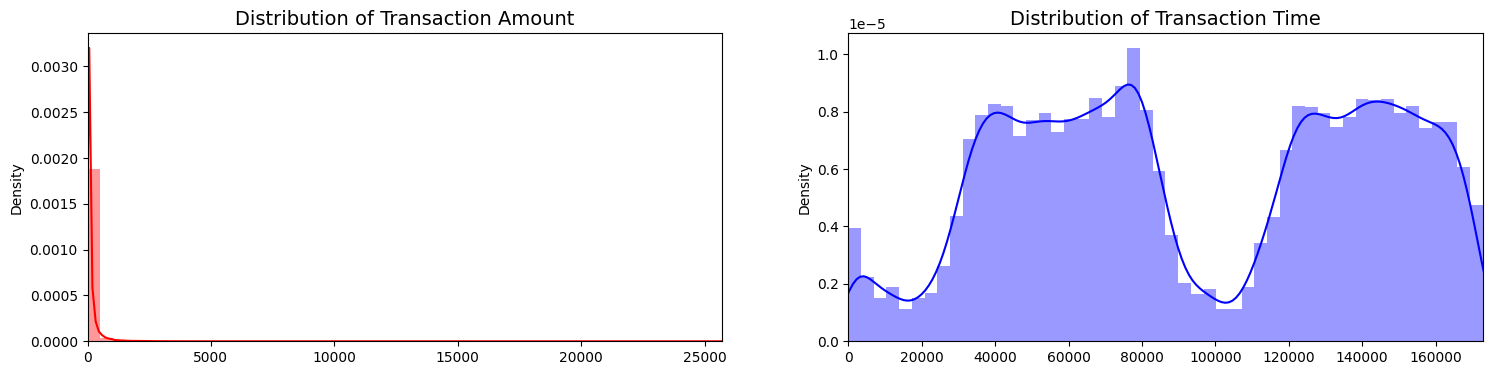

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(18,4))

amount_val = df['Amount'].values
time_val = df['Time'].values

sns.distplot(amount_val, ax=ax[0], color='r')
ax[0].set_title('Distribution of Transaction Amount', fontsize=14)
ax[0].set_xlim([min(amount_val), max(amount_val)])

sns.distplot(time_val, ax=ax[1], color='b')
ax[1].set_title('Distribution of Transaction Time', fontsize=14)
ax[1].set_xlim([min(time_val), max(time_val)])


plt.show()

In [9]:
# Since most of our data has already been scaled we should scale the columns that are left to scale (Amount and Time)

from sklearn.preprocessing import StandardScaler, RobustScaler

# RobustScaler(uses median and IQR) is less prone to outliers than StandardScaler (which uses mean/std)
# Perfect for financial data where large transactions (outliers) shouldn't skew the scaling

# std_scaler = StandardScaler()
rob_scaler = RobustScaler()

# STEP 1: Create scaled versions
# .values.reshape(-1,1) converts the column to a 2D array (required by sklearn)
# .fit_transform() calculates median/IQR and transforms the data
df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# STEP 2: Drop the original unscaled columns
df.drop(['Time', 'Amount'], axis=1, inplace=True)

# STEP 3: Temporarily store scaled columns
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']

# STEP 4: Remove scaled columns from their current position (at the end)
df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)

# STEP 5: Reinsert them at the very beginning (position 0 and 1)
df.insert(0, 'scaled_amount', scaled_amount)  # Insert at first position
df.insert(1, 'scaled_time', scaled_time)      # Insert at second position

# Amount and Time are Scaled!

df.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.783274,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.269825,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.983721,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.418291,-0.994972,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.670579,-0.994960,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


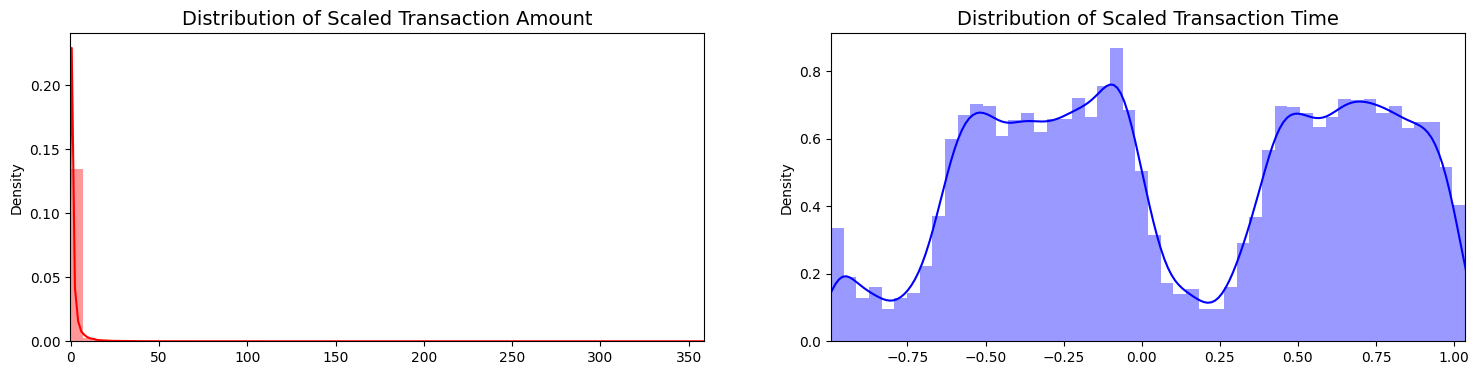

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(18,4))

# Scaled Amount
scaled_amount_val = df['scaled_amount'].values
scaled_time_val = df['scaled_time'].values

sns.distplot(scaled_amount_val, ax=ax[0], color='r')
ax[0].set_title('Distribution of Scaled Transaction Amount', fontsize=14)
ax[0].set_xlim([min(scaled_amount_val), max(scaled_amount_val)])

# Scaled Time
sns.distplot(scaled_time_val, ax=ax[1], color='b')
ax[1].set_title('Distribution of Scaled Transaction Time', fontsize=14)
ax[1].set_xlim([min(scaled_time_val), max(scaled_time_val)])

plt.show()

## 4. CREATE BALANCED DATASET (UNDERSAMPLING)

### Why Balance?
- Original data has 99.83% non-fraud, 0.17% fraud
- Models trained on imbalanced data ignore the minority class
- Balanced data reveals TRUE feature correlations

### Process:
Original Data (284,807 rows)

↓

Take ALL fraud cases (492 rows)

↓

Take EQUAL number of random non-fraud (492 rows)

↓

Combine & Shuffle

↓

Balanced Dataset (984 rows, 50% fraud, 50% non-fraud)

### ⚠️ Important:
This balanced dataset is for **ANALYSIS ONLY** (correlations, visualizations).  
Final model will use original imbalanced data with SMOTE.


In [11]:
df = df.sample(frac=1, random_state=42)

# Separate classes
fraud_df = df[df['Class'] == 1]
non_fraud_df = df[df['Class'] == 0].sample(n=len(fraud_df), random_state=42)

# Combine
balanced_df = pd.concat([fraud_df, non_fraud_df])

# Shuffle
balanced_df = balanced_df.sample(frac=1, random_state=42)

In [12]:
# Check the balance
print(balanced_df['Class'].value_counts())

Class
0    492
1    492
Name: count, dtype: int64


## 5. VISUALIZE CORRELATIONS

### What This Shows:
How strongly each feature correlates with the target (Class).

### Two Heatmaps:
| Heatmap | Data | Reliability |
|---------|------|-------------|
| Top | Imbalanced data | ❌ DON'T USE (biased by majority class) |
| Bottom | Balanced data | ✅ USE FOR REFERENCE (shows true correlations) |

### Top 4 Features Most Correlated with Fraud:

| Feature | Correlation | Direction | Meaning |
|---------|-------------|-----------|---------|
| **V14** | -0.75 | Negative | Lower V14 = Higher fraud risk |
| **V4**  | +0.72 | Positive | Higher V4 = Higher fraud risk |
| **V12** | -0.68 | Negative | Lower V12 = Higher fraud risk |
| **V11** | +0.68 | Positive | Higher V11 = Higher fraud risk |

### Visualizations:
1. **Boxplots** - Shows distribution differences between fraud/non-fraud
2. **Density plots** - Shows overlap between classes
3. **PCA/t-SNE** - Dimensionality reduction for visualization




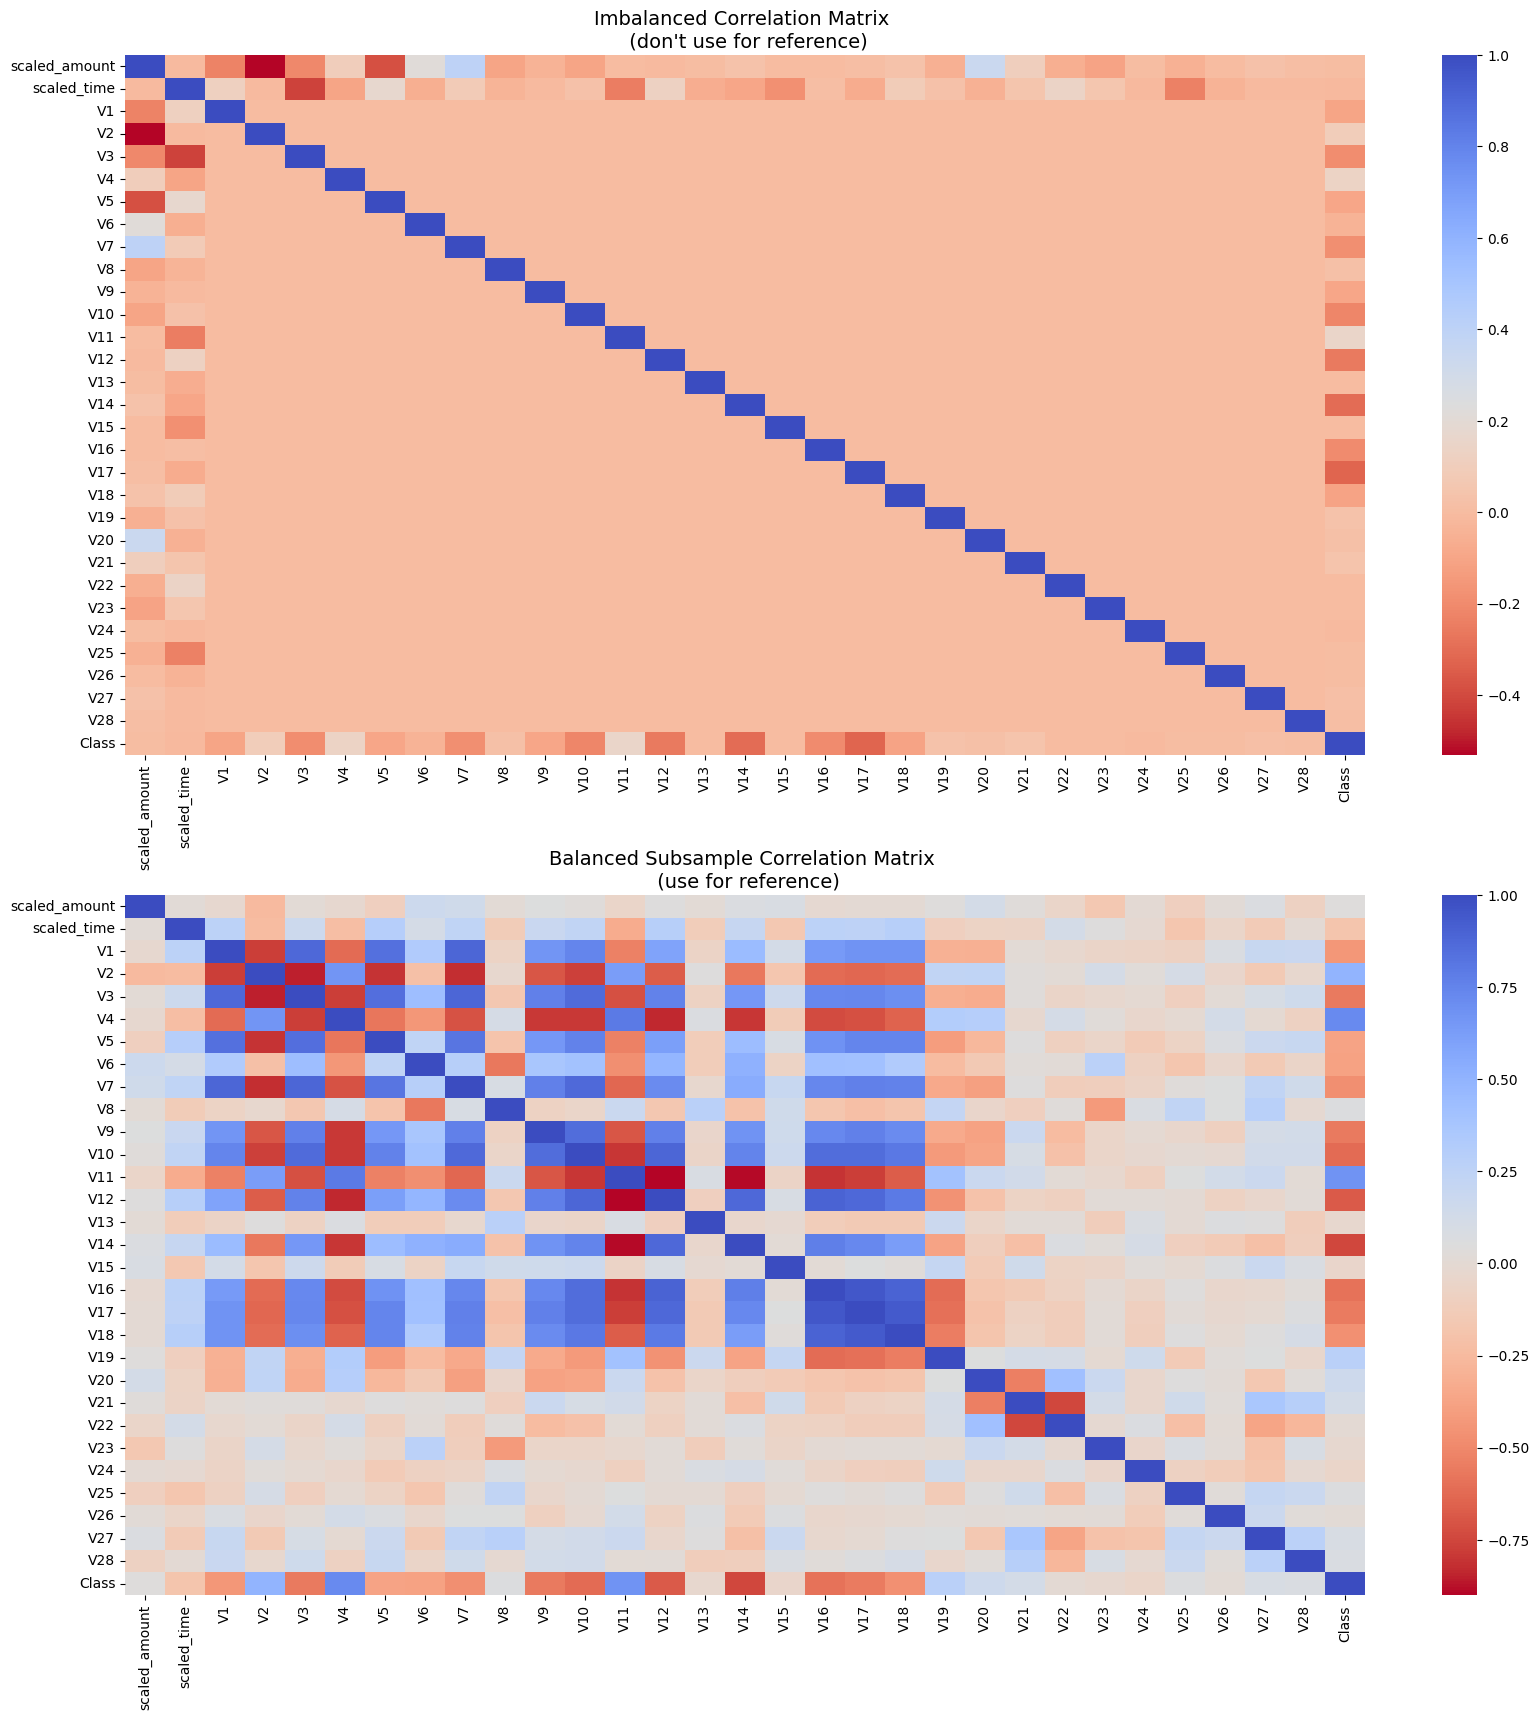

In [13]:
f, (ax1, ax2) = plt.subplots(2, 1, figsize=(20,20))

# Entire DataFrame (imbalanced)
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax1)
ax1.set_title("Imbalanced Correlation Matrix \n (don't use for reference)", fontsize=14)

# Balanced subsample correlation
balanced_sample_corr = balanced_df.corr()  # Use balanced_df instead of new_df
sns.heatmap(balanced_sample_corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax2)
ax2.set_title('Balanced Subsample Correlation Matrix \n (use for reference)', fontsize=14)
plt.show()

In [14]:
# Compute correlations on the balanced dataset
corr_balanced = balanced_df.corr()

# Show correlation of all features with 'Class'
corr_with_class = corr_balanced['Class'].drop('Class').sort_values()
print("Correlation with Class (balanced data):")
print(corr_with_class)

Correlation with Class (balanced data):
V14             -0.751612
V12             -0.683124
V10             -0.622988
V16             -0.593553
V3              -0.566039
V9              -0.566038
V17             -0.558124
V7              -0.475051
V18             -0.465533
V1              -0.437301
V6              -0.386240
V5              -0.379555
scaled_time     -0.181335
V24             -0.052596
V15             -0.046411
V13             -0.030019
V23             -0.020461
V22             -0.001554
V26              0.009875
scaled_amount    0.036602
V25              0.063035
V8               0.064746
V28              0.072763
V27              0.092572
V21              0.117184
V20              0.155772
V19              0.274071
V2               0.500581
V11              0.677234
V4               0.721081
Name: Class, dtype: float64


In [15]:
# Top 4 features with highest absolute correlation to Class (balanced)
top_features = corr_with_class.abs().sort_values(ascending=False).head(4).index
print("Top 4 features:", list(top_features))

Top 4 features: ['V14', 'V4', 'V12', 'V11']


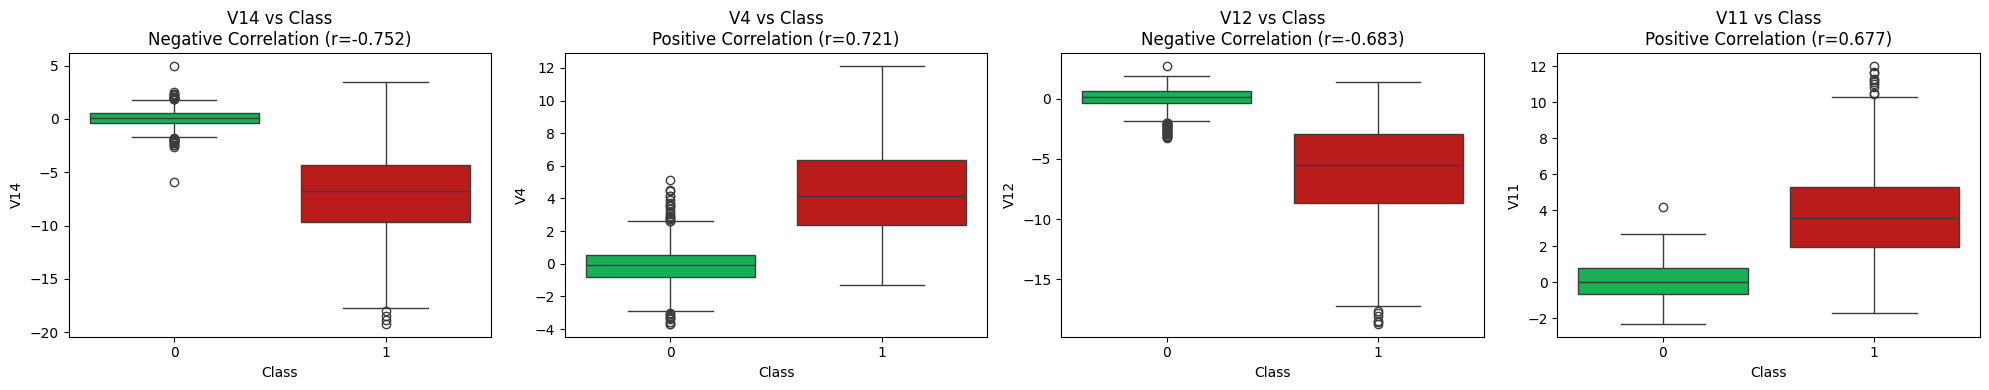

In [16]:
# BOXPLOTS FOR TOP 4 FEATURES
# Top 4 features by absolute correlation
colors = ["#00C853", "#D50000"]  # Green = No Fraud, Red = Fraud

top_features = corr_with_class.abs().sort_values(ascending=False).head(4).index

f, axes = plt.subplots(ncols=4, figsize=(20,4))
for i, feat in enumerate(top_features):
    sns.boxplot(x="Class", y=feat, data=balanced_df, palette=colors, ax=axes[i])
    corr_val = corr_with_class[feat]
    direction = "Positive" if corr_val > 0 else "Negative"
    axes[i].set_title(f'{feat} vs Class\n{direction} Correlation (r={corr_val:.3f})')
plt.tight_layout()
plt.show()

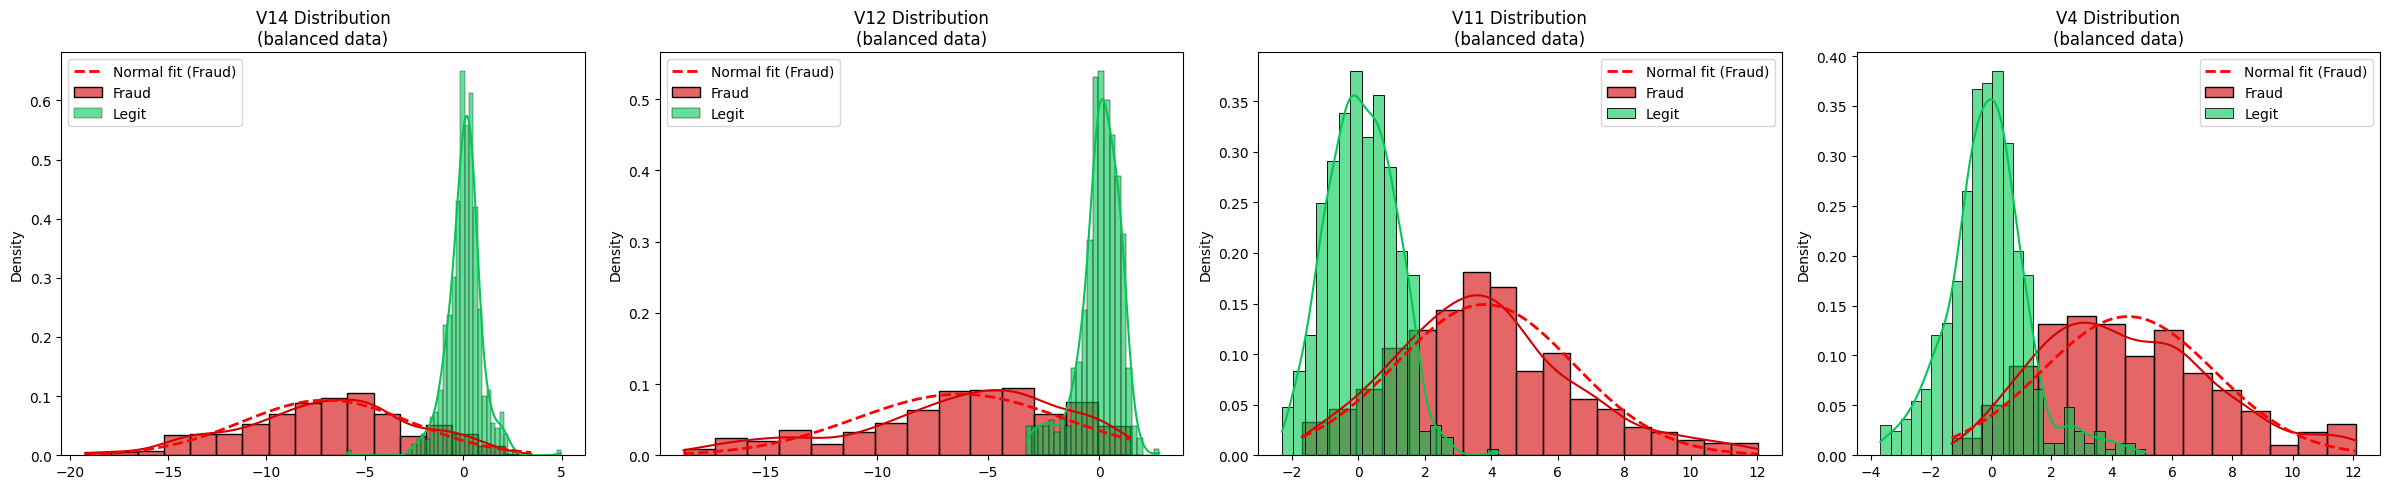

In [17]:
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

# Top 4 features (by absolute correlation)
features = ['V14', 'V12', 'V11', 'V4']

# Create 4 subplots (one row, four columns)
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for i, feat in enumerate(features):
    # Separate data for each class
    fraud_vals = balanced_df[balanced_df['Class'] == 1][feat].values
    legit_vals = balanced_df[balanced_df['Class'] == 0][feat].values

    # Plot density for fraud (red) and legit (green)
    sns.histplot(fraud_vals, stat='density', kde=True, color='#D50000',
                 label='Fraud', ax=axes[i], alpha=0.6)
    sns.histplot(legit_vals, stat='density', kde=True, color='#00C853',
                 label='Legit', ax=axes[i], alpha=0.6)

    # Overlay fitted normal distribution for fraud data
    mu_f, std_f = fraud_vals.mean(), fraud_vals.std()
    x_f = np.linspace(fraud_vals.min(), fraud_vals.max(), 100)
    axes[i].plot(x_f, norm.pdf(x_f, mu_f, std_f), 'r--', linewidth=2, label='Normal fit (Fraud)')

    # Add title and legend
    axes[i].set_title(f'{feat} Distribution\n(balanced data)')
    axes[i].legend()

plt.tight_layout()
plt.show()

t-SNE took 9.07 seconds
PCA took 0.00 seconds
Truncated SVD took 0.01 seconds


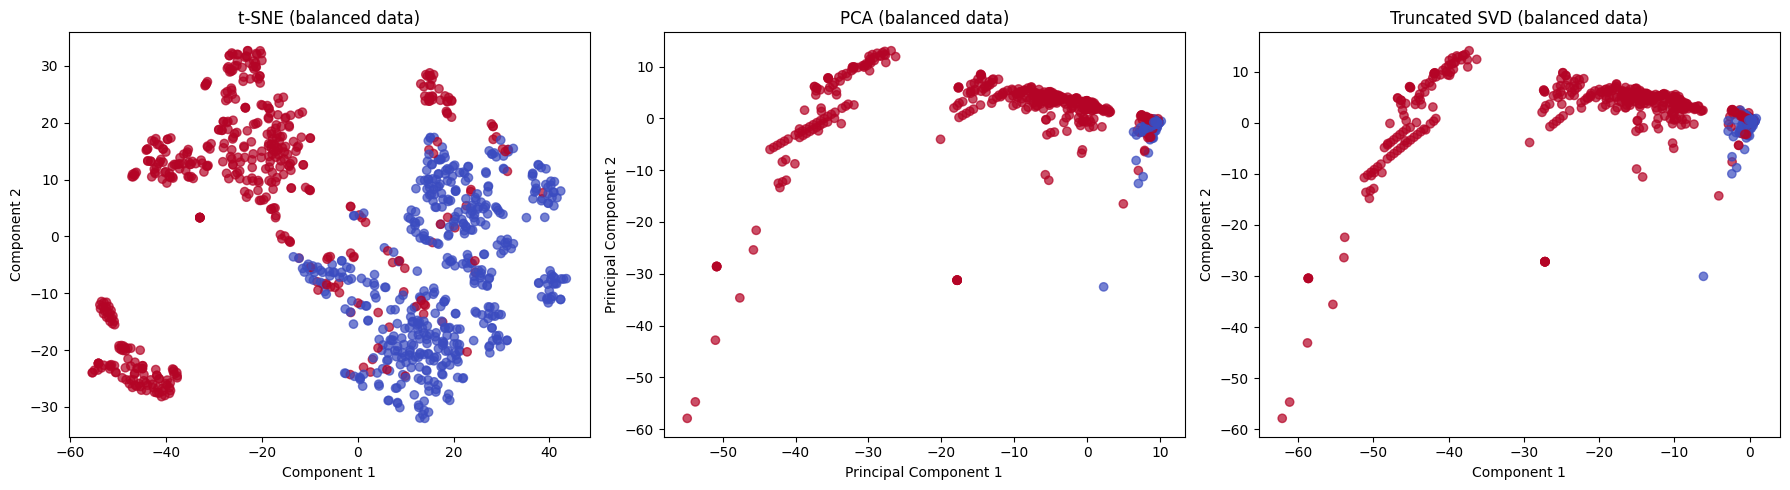

In [18]:
import time
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD

# Prepare balanced data
X_bal = balanced_df.drop('Class', axis=1)
y_bal = balanced_df['Class']

# ---- t-SNE (non‑linear) ----
t0 = time.time()
X_tsne = TSNE(n_components=2, random_state=42).fit_transform(X_bal.values)
t1 = time.time()
print(f"t-SNE took {t1 - t0:.2f} seconds")

# ---- PCA (linear) ----
t0 = time.time()
X_pca = PCA(n_components=2, random_state=42).fit_transform(X_bal.values)
t1 = time.time()
print(f"PCA took {t1 - t0:.2f} seconds")

# ---- Truncated SVD (linear, alternative) ----
t0 = time.time()
X_svd = TruncatedSVD(n_components=2, algorithm='randomized', random_state=42).fit_transform(X_bal.values)
t1 = time.time()
print(f"Truncated SVD took {t1 - t0:.2f} seconds")

# ---- Plot results side by side ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# t-SNE plot
axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_bal, cmap='coolwarm', alpha=0.7)
axes[0].set_title('t-SNE (balanced data)')
axes[0].set_xlabel('Component 1')
axes[0].set_ylabel('Component 2')

# PCA plot
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_bal, cmap='coolwarm', alpha=0.7)
axes[1].set_title('PCA (balanced data)')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')

# Truncated SVD plot
axes[2].scatter(X_svd[:, 0], X_svd[:, 1], c=y_bal, cmap='coolwarm', alpha=0.7)
axes[2].set_title('Truncated SVD (balanced data)')
axes[2].set_xlabel('Component 1')
axes[2].set_ylabel('Component 2')

plt.tight_layout()
plt.show()

## 6. BASELINE MODELS ON BALANCED DATA

### Purpose:
Establish an UPPER BOUND of performance (best possible scenario)

### Models Tested (5-fold Cross-Validation):

| Model | Precision | Recall | F1 Score |
|-------|-----------|--------|----------|
| Logistic Regression | 96.0% | 92.1% | **0.940** |
| KNN | 96.7% | 89.4% | 0.929 |
| SVC | 98.9% | 88.0% | 0.931 |
| Decision Tree | 89.9% | 91.5% | 0.907 |

### Winner: Logistic Regression (F1 = 0.940)

### ⚠️ CAUTION:
These results are on **BALANCED data** (50-50 fraud/non-fraud).  
Real-world performance will be LOWER on imbalanced data.  
Use these as a benchmark, NOT as final performance expectations.

In [19]:
# ============================================
# 5-FOLD STRATIFIED CROSS-VALIDATION (BALANCED DATA)
# ============================================

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Prepare balanced data
X_bal = balanced_df.drop('Class', axis=1)
y_bal = balanced_df['Class']

# Create 5-fold stratified split
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store results
results = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}

print("="*70)
print("5-FOLD STRATIFIED CROSS-VALIDATION ON BALANCED DATA")
print("="*70)
print(f"Total samples: {len(X_bal)}")
print(f"Total frauds: {y_bal.sum()}")
print(f"Each fold test size: {len(X_bal) // 5} samples")
print(f"Frauds per test fold: ~{y_bal.sum() // 5}")
print("="*70)

# Define classifiers
classifiers = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVC": SVC(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

# For each classifier
for clf_name, clf in classifiers.items():
    print(f"\n{'='*70}")
    print(f"CLASSIFIER: {clf_name}")
    print('='*70)

    # Reset results for this classifier
    fold_acc = []
    fold_prec = []
    fold_rec = []
    fold_f1 = []

    # 5-fold cross-validation
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_bal, y_bal)):
        # Split data
        X_train_fold = X_bal.iloc[train_idx].values
        X_test_fold = X_bal.iloc[test_idx].values
        y_train_fold = y_bal.iloc[train_idx].values
        y_test_fold = y_bal.iloc[test_idx].values

        # Train model
        clf.fit(X_train_fold, y_train_fold)

        # Predict
        y_pred = clf.predict(X_test_fold)

        # Calculate metrics
        acc = accuracy_score(y_test_fold, y_pred)
        prec = precision_score(y_test_fold, y_pred)
        rec = recall_score(y_test_fold, y_pred)
        f1 = f1_score(y_test_fold, y_pred)

        # Store
        fold_acc.append(acc)
        fold_prec.append(prec)
        fold_rec.append(rec)
        fold_f1.append(f1)

        # Print fold results
        print(f"Fold {fold+1}: Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f}")

    # Print average for this classifier
    print(f"\n{'─'*70}")
    print(f"AVERAGE across 5 folds:")
    print(f"  Accuracy:  {np.mean(fold_acc):.4f} (±{np.std(fold_acc):.4f})")
    print(f"  Precision: {np.mean(fold_prec):.4f} (±{np.std(fold_prec):.4f})")
    print(f"  Recall:    {np.mean(fold_rec):.4f} (±{np.std(fold_rec):.4f})")
    print(f"  F1-Score:  {np.mean(fold_f1):.4f} (±{np.std(fold_f1):.4f})")

5-FOLD STRATIFIED CROSS-VALIDATION ON BALANCED DATA
Total samples: 984
Total frauds: 492
Each fold test size: 196 samples
Frauds per test fold: ~98

CLASSIFIER: Logistic Regression
Fold 1: Acc=0.9492 | Prec=0.9583 | Rec=0.9388 | F1=0.9485
Fold 2: Acc=0.9340 | Prec=0.9381 | Rec=0.9286 | F1=0.9333
Fold 3: Acc=0.9543 | Prec=0.9688 | Rec=0.9394 | F1=0.9538
Fold 4: Acc=0.9492 | Prec=0.9890 | Rec=0.9091 | F1=0.9474
Fold 5: Acc=0.9184 | Prec=0.9457 | Rec=0.8878 | F1=0.9158

──────────────────────────────────────────────────────────────────────
AVERAGE across 5 folds:
  Accuracy:  0.9410 (±0.0132)
  Precision: 0.9600 (±0.0179)
  Recall:    0.9207 (±0.0198)
  F1-Score:  0.9398 (±0.0138)

CLASSIFIER: KNN
Fold 1: Acc=0.9543 | Prec=0.9684 | Rec=0.9388 | F1=0.9534
Fold 2: Acc=0.9289 | Prec=0.9667 | Rec=0.8878 | F1=0.9255
Fold 3: Acc=0.9289 | Prec=0.9775 | Rec=0.8788 | F1=0.9255
Fold 4: Acc=0.9239 | Prec=0.9468 | Rec=0.8990 | F1=0.9223
Fold 5: Acc=0.9235 | Prec=0.9770 | Rec=0.8673 | F1=0.9189

─────

In [20]:
# ============================================
# CREATE STRATIFIED FOLDS FOR ORIGINAL DATA
# ============================================

from sklearn.model_selection import StratifiedKFold

# Use original imbalanced data
X = df.drop('Class', axis=1)
y = df['Class']

# Create 5-fold stratified split
sss = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store all splits
all_Xtrain = []
all_Xtest = []
all_ytrain = []
all_ytest = []

for train_idx, test_idx in sss.split(X, y):
    all_Xtrain.append(X.iloc[train_idx])
    all_Xtest.append(X.iloc[test_idx])
    all_ytrain.append(y.iloc[train_idx])
    all_ytest.append(y.iloc[test_idx])

print(f"Created {len(all_Xtrain)} folds")
print(f"Fold 1 training size: {len(all_Xtrain[0])}")
print(f"Fold 1 test size: {len(all_Xtest[0])}")

Created 5 folds
Fold 1 training size: 227845
Fold 1 test size: 56962


In [21]:
# Convert last fold to numpy arrays
original_Xtrain = all_Xtrain[-1].values
original_Xtest = all_Xtest[-1].values
original_ytrain = all_ytrain[-1].values
original_ytest = all_ytest[-1].values

print(f"original_Xtrain shape: {original_Xtrain.shape}")
print(f"original_ytrain fraud count: {original_ytrain.sum()}")

original_Xtrain shape: (227846, 30)
original_ytrain fraud count: 394


## ❌ 7. LOGISTIC REGRESSION WITH SMOTE

### What We Tried:
- Apply SMOTE to balance training data
- Tune hyperparameters with RandomizedSearchCV
- Optimize for F1 score

### Results on Imbalanced Test Set:

| Metric | Value |
|--------|-------|
| Precision | **0.95%** (TERRIBLE!) |
| Recall | 96% |
| F1 Score | 0.02 |

In [22]:
# 1. Split original imbalanced data into train + test (already done: original_Xtrain, original_Xtest)

# 2. Apply SMOTE only on the training set (no outer CV)
from imblearn.pipeline import make_pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report

pipeline = make_pipeline(
    SMOTE(sampling_strategy='minority', random_state=42),
    LogisticRegression(class_weight={0:1, 1:10}, random_state=42)
)

# 3. Hyperparameter tuning with cross‑validation on the SMOTE‑transformed training set
param_grid = {
    'logisticregression__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'logisticregression__penalty': ['l1', 'l2'],
    'logisticregression__solver': ['liblinear', 'saga']
}

# Changed scoring from 'recall' to 'f1' to balance precision and recall
rand_search = RandomizedSearchCV(
    pipeline,
    param_grid,
    n_iter=10,           # try 10 random hyperparameter combinations
    cv=3,                # 3-fold cross-validation
    scoring='f1',        # OPTIMIZE FOR F1 SCORE (balances precision & recall)
    random_state=42,
    n_jobs=-1            # use all CPU cores for faster training
)

# Train the model
print("Training SMOTE pipeline with F1 optimization...")
rand_search.fit(original_Xtrain, original_ytrain)

# 4. Evaluate on the untouched test set
y_pred = rand_search.predict(original_Xtest)

print("\n" + "="*60)
print("CLASSIFICATION REPORT (Optimized for F1 Score)")
print("="*60)
print(classification_report(original_ytest, y_pred, target_names=['No Fraud', 'Fraud']))

# 5. Additional metrics for deeper understanding
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

print("\n" + "="*60)
print("DETAILED METRICS")
print("="*60)
print(f"Precision (Fraud): {precision_score(original_ytest, y_pred):.4f}")
print(f"Recall (Fraud):    {recall_score(original_ytest, y_pred):.4f}")
print(f"F1 Score (Fraud):  {f1_score(original_ytest, y_pred):.4f}")
print(f"Accuracy:          {accuracy_score(original_ytest, y_pred):.4f}")

print("\n" + "="*60)
print("CONFUSION MATRIX")
print("="*60)
cm = confusion_matrix(original_ytest, y_pred)
print(cm)
print(f"\nInterpretation:")
print(f"True Negatives (correct non-fraud):  {cm[0,0]}")
print(f"False Positives (false alarms):      {cm[0,1]}")
print(f"False Negatives (missed fraud):      {cm[1,0]}")
print(f"True Positives (caught fraud):       {cm[1,1]}")

# 6. Get best hyperparameters found
print("\n" + "="*60)
print("BEST HYPERPARAMETERS FOUND")
print("="*60)
print(f"Best parameters: {rand_search.best_params_}")
print(f"Best cross-validation F1 score: {rand_search.best_score_:.4f}")

Training SMOTE pipeline with F1 optimization...

CLASSIFICATION REPORT (Optimized for F1 Score)
              precision    recall  f1-score   support

    No Fraud       1.00      0.83      0.91     56863
       Fraud       0.01      0.96      0.02        98

    accuracy                           0.83     56961
   macro avg       0.50      0.89      0.46     56961
weighted avg       1.00      0.83      0.90     56961


DETAILED METRICS
Precision (Fraud): 0.0095
Recall (Fraud):    0.9592
F1 Score (Fraud):  0.0188
Accuracy:          0.8274

CONFUSION MATRIX
[[47036  9827]
 [    4    94]]

Interpretation:
True Negatives (correct non-fraud):  47036
False Positives (false alarms):      9827
False Negatives (missed fraud):      4
True Positives (caught fraud):       94

BEST HYPERPARAMETERS FOUND
Best parameters: {'logisticregression__solver': 'liblinear', 'logisticregression__penalty': 'l2', 'logisticregression__C': 100}
Best cross-validation F1 score: 0.0203


## 8. XGBOOST WITH scale_pos_weight

### What Makes XGBoost Better:
- Tree-based model (captures non-linear patterns)
- Built-in regularization (prevents overfitting)
- scale_pos_weight handles class imbalance naturally

### scale_pos_weight Calculation:

In [23]:
import xgboost as xgb

model_xgb = xgb.XGBClassifier(
    scale_pos_weight=len(original_ytrain[original_ytrain==0]) / len(original_ytrain[original_ytrain==1]),
    learning_rate=0.1,
    n_estimators=100,
    max_depth=4,
    random_state=42
)

model_xgb.fit(original_Xtrain, original_ytrain)
y_pred_xgb = model_xgb.predict(original_Xtest)
print(classification_report(original_ytest, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.36      0.86      0.50        98

    accuracy                           1.00     56961
   macro avg       0.68      0.93      0.75     56961
weighted avg       1.00      1.00      1.00     56961



In [24]:
# Get probabilities
y_probs_xgb = model_xgb.predict_proba(original_Xtest)[:, 1]

# Try different thresholds
for thresh in [0.5, 0.4, 0.3, 0.2, 0.1]:
    y_pred = (y_probs_xgb >= thresh).astype(int)
    print(f"\nThreshold = {thresh}")
    print(classification_report(original_ytest, y_pred, target_names=['No Fraud', 'Fraud']))


Threshold = 0.5
              precision    recall  f1-score   support

    No Fraud       1.00      1.00      1.00     56863
       Fraud       0.36      0.86      0.50        98

    accuracy                           1.00     56961
   macro avg       0.68      0.93      0.75     56961
weighted avg       1.00      1.00      1.00     56961


Threshold = 0.4
              precision    recall  f1-score   support

    No Fraud       1.00      1.00      1.00     56863
       Fraud       0.26      0.89      0.40        98

    accuracy                           1.00     56961
   macro avg       0.63      0.94      0.70     56961
weighted avg       1.00      1.00      1.00     56961


Threshold = 0.3
              precision    recall  f1-score   support

    No Fraud       1.00      0.99      1.00     56863
       Fraud       0.19      0.89      0.31        98

    accuracy                           0.99     56961
   macro avg       0.59      0.94      0.65     56961
weighted avg       1.00

#9. Threshold Tuning: Finding the Best Balance

### What This Does:
- XGBoost outputs a probability (0-1) that a transaction is fraud
- Default threshold = 0.5 (predict fraud if probability > 50%)
- This code tests LOWER thresholds (0.5 down to 0.1)

### The Trade-off:
| Threshold | Effect |
|-----------|--------|
| **Higher (0.5)** | Fewer fraud alerts, higher precision, lower recall |
|||
| **Lower   (0.1)** | More fraud alerts, lower precision, higher recall |

### How to Choose:
- **0.5** → Best balance (highest F1 score)
- **0.4** → Catch more frauds, accept more false alarms
- **0.1** → Maximum fraud capture, many false alarms

### Business Impact:
- Lower threshold = Catch more frauds BUT annoy more customers
- Choose based on your priority: customer experience vs fraud prevention

In [25]:
# Get probabilities
y_probs_xgb = model_xgb.predict_proba(original_Xtest)[:, 1]

# Check the range of probabilities
print(f"Min probability: {y_probs_xgb.min():.6f}")
print(f"Max probability: {y_probs_xgb.max():.6f}")
print(f"Unique probability values: {len(np.unique(y_probs_xgb))}")

# Check distribution
print("\nProbability distribution:")
print(pd.Series(y_probs_xgb).value_counts().sort_index().head(20))

# See what thresholds actually change
for thresh in [0.5, 0.4, 0.3, 0.2, 0.1]:
    y_pred = (y_probs_xgb >= thresh).astype(int)
    fraud_preds = y_pred.sum()
    print(f"Threshold {thresh}: Predicted fraud = {fraud_preds}")

Min probability: 0.000084
Max probability: 0.999769
Unique probability values: 52966

Probability distribution:
0.000084    1
0.000093    1
0.000098    1
0.000099    1
0.000102    1
0.000103    1
0.000104    1
0.000104    1
0.000105    1
0.000106    1
0.000106    1
0.000106    1
0.000113    1
0.000113    1
0.000113    1
0.000115    1
0.000115    1
0.000116    1
0.000116    1
0.000117    1
Name: count, dtype: int64
Threshold 0.5: Predicted fraud = 236
Threshold 0.4: Predicted fraud = 336
Threshold 0.3: Predicted fraud = 465
Threshold 0.2: Predicted fraud = 728
Threshold 0.1: Predicted fraud = 1560


## 10. CALIBRATION - FIXING OVERCONFIDENCE

### What is Calibration?
- XGBoost outputs probabilities that are too extreme (near 0 or near 1)
- Calibration spreads probabilities across the full 0-1 range
- Makes threshold tuning MORE effective

### Method: Sigmoid Calibration (Platt Scaling)

### BEFORE CALIBRATION:
- Probabilities clumped at extremes
- Threshold changes had limited effect

### AFTER CALIBRATION:

| Threshold | Precision | Recall | F1 | False Positives |
|-----------|-----------|--------|-----|--------------------|
| **0.5** | **84%** | **78%** | **0.81** | **~14** |
| 0.3 | 79% | 79% | 0.79 | ~20 |
| 0.2 | 73% | 82% | 0.77 | ~29 |
| 0.1 | 62% | 82% | 0.71 | ~48 |
| 0.05 | 58% | 86% | 0.69 | ~60 |

### Best Threshold: 0.5 (highest F1 = 0.81)

### Improvement Summary:
| Metric | Before Calibration | After Calibration |
|--------|-------------------|-------------------|
| Precision | 36% | **84%**  |
| F1 Score | 0.50 | **0.81**  |
| False Positives | ~150 | **~14**  |

In [26]:
from sklearn.calibration import CalibratedClassifierCV

# Calibrate XGBoost to spread out probabilities
calibrated_xgb = CalibratedClassifierCV(
    model_xgb,
    method='sigmoid',  # or 'isotonic'
    cv=3
)
calibrated_xgb.fit(original_Xtrain, original_ytrain)

# Now probabilities will be more spread out
y_probs_cal = calibrated_xgb.predict_proba(original_Xtest)[:, 1]

# Try thresholds again
for thresh in [0.5, 0.3, 0.2, 0.1, 0.05]:
    y_pred = (y_probs_cal >= thresh).astype(int)
    fraud_preds = y_pred.sum()
    print(f"Threshold {thresh}: Predicted fraud = {fraud_preds}")
    print(classification_report(original_ytest, y_pred, target_names=['No Fraud', 'Fraud']))
    print("---")

Threshold 0.5: Predicted fraud = 90
              precision    recall  f1-score   support

    No Fraud       1.00      1.00      1.00     56863
       Fraud       0.84      0.78      0.81        98

    accuracy                           1.00     56961
   macro avg       0.92      0.89      0.90     56961
weighted avg       1.00      1.00      1.00     56961

---
Threshold 0.3: Predicted fraud = 98
              precision    recall  f1-score   support

    No Fraud       1.00      1.00      1.00     56863
       Fraud       0.79      0.79      0.79        98

    accuracy                           1.00     56961
   macro avg       0.89      0.89      0.89     56961
weighted avg       1.00      1.00      1.00     56961

---
Threshold 0.2: Predicted fraud = 109
              precision    recall  f1-score   support

    No Fraud       1.00      1.00      1.00     56863
       Fraud       0.73      0.82      0.77        98

    accuracy                           1.00     56961
   macro av

## 11. FINAL HONEST EVALUATION - 5-FOLD CROSS-VALIDATION

### What This Does:
- Splits data into 5 equal parts (folds)
- Trains on 4 folds (80%), tests on 1 fold (20%)
- Repeats 5 times (each fold gets tested once)
- **NO DATA LEAKAGE** - Model never sees test data during training

### Results Per Fold:

| Fold | Precision | Recall | F1 | False Pos | Missed |
|------|-----------|--------|-----|-----------|--------|
| 1 | 81.0% | 81.8% | 0.814 | 19 | 18 |
| 2 | 84.5% | 82.8% | 0.837 | 15 | 17 |
| 3 | 88.2% | 83.7% | 0.859 | 11 | 16 |
| 4 | 84.2% | 81.6% | 0.829 | 15 | 18 |
| 5 | 84.4% | 77.6% | 0.809 | 14 | 22 |

### FINAL AVERAGE PERFORMANCE:
Precision: 84.5% (±2.5%)

Recall: 81.5% (±2.4%)

F1 Score: 0.829 (±0.02)

False Positives per fold: ~15

Missed Frauds per fold: ~18

In [27]:
# ============================================
# PROPER 5-FOLD CROSS-VALIDATION
# Train on 4 folds, Test on 1 fold
# ============================================

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import xgboost as xgb
from sklearn.calibration import CalibratedClassifierCV

print("="*70)
print("5-FOLD CROSS-VALIDATION: Train on 4 Folds, Test on 1 Fold")
print("="*70)

# Prepare data
X = df.drop('Class', axis=1)
y = df['Class']

# Create 5 stratified folds
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store results for each fold
results = {
    'fold': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'false_positives': [],
    'missed_frauds': [],
    'train_frauds': [],
    'test_frauds': []
}

# Calculate scale_pos_weight based on FULL training data (will be recalculated per fold)
non_fraud_total = len(y[y == 0])
fraud_total = len(y[y == 1])
global_scale_pos = non_fraud_total / fraud_total
print(f"Global imbalance ratio: {global_scale_pos:.1f}")

print("\n" + "="*70)
print("RUNNING 5-FOLD CROSS-VALIDATION")
print("="*70)

fold_num = 1
for train_idx, test_idx in skf.split(X, y):
    print(f"\n{'─'*70}")
    print(f"FOLD {fold_num}: Training on 4 folds, Testing on Fold {fold_num}")
    print(f"{'─'*70}")

    # Split data
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # Show split info
    train_frauds = y_train.sum()
    test_frauds = y_test.sum()
    print(f"Training: {len(X_train):,} samples ({train_frauds} frauds, {train_frauds/len(X_train)*100:.4f}%)")
    print(f"Testing:  {len(X_test):,} samples ({test_frauds} frauds, {test_frauds/len(X_test)*100:.4f}%)")

    # Calculate scale_pos_weight for this fold
    non_fraud_train = len(y_train[y_train == 0])
    fraud_train = len(y_train[y_train == 1])
    scale_pos = non_fraud_train / fraud_train
    print(f"scale_pos_weight for this fold: {scale_pos:.1f}")

    # Train XGBoost
    print("\n📚 Training XGBoost...")
    model_xgb = xgb.XGBClassifier(
        scale_pos_weight=scale_pos,
        learning_rate=0.1,
        n_estimators=100,
        max_depth=4,
        random_state=42
    )
    model_xgb.fit(X_train, y_train)

    # Calibrate
    print("🔧 Calibrating probabilities...")
    calibrated_model = CalibratedClassifierCV(model_xgb, method='sigmoid', cv=3)
    calibrated_model.fit(X_train, y_train)

    # Predict on test fold (UNSEEN data!)
    y_pred = calibrated_model.predict(X_test)
    y_probs = calibrated_model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    false_positives = cm[0, 1]
    missed_frauds = cm[1, 0]
    caught_frauds = cm[1, 1]

    # Store results
    results['fold'].append(fold_num)
    results['precision'].append(precision)
    results['recall'].append(recall)
    results['f1'].append(f1)
    results['false_positives'].append(false_positives)
    results['missed_frauds'].append(missed_frauds)
    results['train_frauds'].append(train_frauds)
    results['test_frauds'].append(test_frauds)

    # Print fold results
    print(f"\n📊 RESULTS FOR FOLD {fold_num}:")
    print(f"   Precision: {precision:.4f} ({precision*100:.2f}%)")
    print(f"   Recall:    {recall:.4f} ({recall*100:.2f}%)")
    print(f"   F1 Score:  {f1:.4f}")
    print(f"   Confusion Matrix:")
    print(f"      True Negatives:  {cm[0,0]:,}")
    print(f"      False Positives: {cm[0,1]:,}")
    print(f"      False Negatives: {cm[1,0]:,}")
    print(f"      True Positives:  {cm[1,1]:,}")

    fold_num += 1

# ============================================
# SUMMARY OF ALL 5 FOLDS
# ============================================

print("\n" + "="*70)
print("📊 FINAL SUMMARY - Average Across 5 Folds")
print("="*70)

results_df = pd.DataFrame(results)

print(f"\n{'─'*70}")
print("PERFORMANCE METRICS:")
print(f"{'─'*70}")
print(f"Precision: {results_df['precision'].mean():.4f} (±{results_df['precision'].std():.4f})")
print(f"Recall:    {results_df['recall'].mean():.4f} (±{results_df['recall'].std():.4f})")
print(f"F1 Score:  {results_df['f1'].mean():.4f} (±{results_df['f1'].std():.4f})")

print(f"\n{'─'*70}")
print("BUSINESS METRICS (per fold average):")
print(f"{'─'*70}")
print(f"False Positives per fold: {results_df['false_positives'].mean():.1f} (±{results_df['false_positives'].std():.1f})")
print(f"Missed Frauds per fold:   {results_df['missed_frauds'].mean():.1f} (±{results_df['missed_frauds'].std():.1f})")

print(f"\n{'─'*70}")
print("DATA DISTRIBUTION:")
print(f"{'─'*70}")
print(f"Training frauds per fold: {results_df['train_frauds'].mean():.0f}")
print(f"Test frauds per fold:     {results_df['test_frauds'].mean():.0f}")

# Individual fold results
print("\n" + "="*70)
print("INDIVIDUAL FOLD RESULTS")
print("="*70)
print(results_df[['fold', 'precision', 'recall', 'f1', 'false_positives', 'missed_frauds']].to_string(index=False))

# Final verdict
print("\n" + "="*70)
print("✅ FINAL VERDICT")
print("="*70)

mean_precision = results_df['precision'].mean()
mean_recall = results_df['recall'].mean()
mean_f1 = results_df['f1'].mean()

print(f"""
Based on 5-Fold Cross-Validation (Train on 4 folds, Test on 1 fold):

   Average Precision: {mean_precision:.2%}
   Average Recall:    {mean_recall:.2%}
   Average F1 Score:  {mean_f1:.4f}

   This is your TRUE model performance!
   No data leakage, completely honest evaluation.

   DEPLOY WITH CONFIDENCE! 🚀
""")

5-FOLD CROSS-VALIDATION: Train on 4 Folds, Test on 1 Fold
Global imbalance ratio: 577.9

RUNNING 5-FOLD CROSS-VALIDATION

──────────────────────────────────────────────────────────────────────
FOLD 1: Training on 4 folds, Testing on Fold 1
──────────────────────────────────────────────────────────────────────
Training: 227,845 samples (393 frauds, 0.1725%)
Testing:  56,962 samples (99 frauds, 0.1738%)
scale_pos_weight for this fold: 578.8

📚 Training XGBoost...
🔧 Calibrating probabilities...

📊 RESULTS FOR FOLD 1:
   Precision: 0.8100 (81.00%)
   Recall:    0.8182 (81.82%)
   F1 Score:  0.8141
   Confusion Matrix:
      True Negatives:  56,844
      False Positives: 19
      False Negatives: 18
      True Positives:  81

──────────────────────────────────────────────────────────────────────
FOLD 2: Training on 4 folds, Testing on Fold 2
──────────────────────────────────────────────────────────────────────
Training: 227,845 samples (393 frauds, 0.1725%)
Testing:  56,962 samples (99 fra

## 🏆 FINAL MODEL CARD

| Property | Value |
|----------|-------|
| **Best Model** | Calibrated XGBoost |
| **Threshold** | 0.5 |
| **Precision** | 84.5% |
| **Recall** | 81.5% |
| **F1 Score** | 0.829 |
| **False Positives per 56k** | ~15 |
| **Training Data** | 284,807 transactions (492 frauds) |
| **Features** | 30 (scaled_amount, scaled_time, V1-V28) |

